<a href="https://colab.research.google.com/github/ueki5/colaboratory/blob/main/playground_023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1
!pip install japanize-matplotlib | tail -n 1
!pip install plotly | tail -n 1

In [10]:
# 共通関数のクローン
!git clone https://github.com/ueki5/pythonlibs.git
# 共通関数のインポート
from pythonlibs.torch_lib1 import (
    eval_loss,
    fit,
    evaluate_history,
    show_images_labels,
    torch_seed,
  )
# 共通関数の存在チェック
print(README)

fatal: destination path 'pythonlibs' already exists and is not an empty directory.
Common Library for PyTorch
Author: M. Akaishi


cpu
# 入力データの確認（１階テンソル版）
訓練データの件数: 50000
訓練データの型： <class 'torch.Tensor'>
訓練データのshape： torch.Size([3072])
最小値： tensor(-1.)
最大値： tensor(1.)
検証データの件数: 10000
検証データの型： <class 'torch.Tensor'>
検証データのshape： torch.Size([3072])
最小値： tensor(-0.8980)
最大値： tensor(1.)
# 入力データの確認（３階テンソル版）
訓練データの件数: 50000
訓練データの型： <class 'torch.Tensor'>
訓練データのshape： torch.Size([3, 32, 32])
最小値： tensor(-1.)
最大値： tensor(1.)
検証データの件数: 10000
検証データの型： <class 'torch.Tensor'>
検証データのshape： torch.Size([3, 32, 32])
最小値： tensor(-0.8980)
最大値： tensor(1.)
１階テンソル版のshape:torch.Size([500, 3072])
３階テンソル版のshape:torch.Size([500, 3, 32, 32])


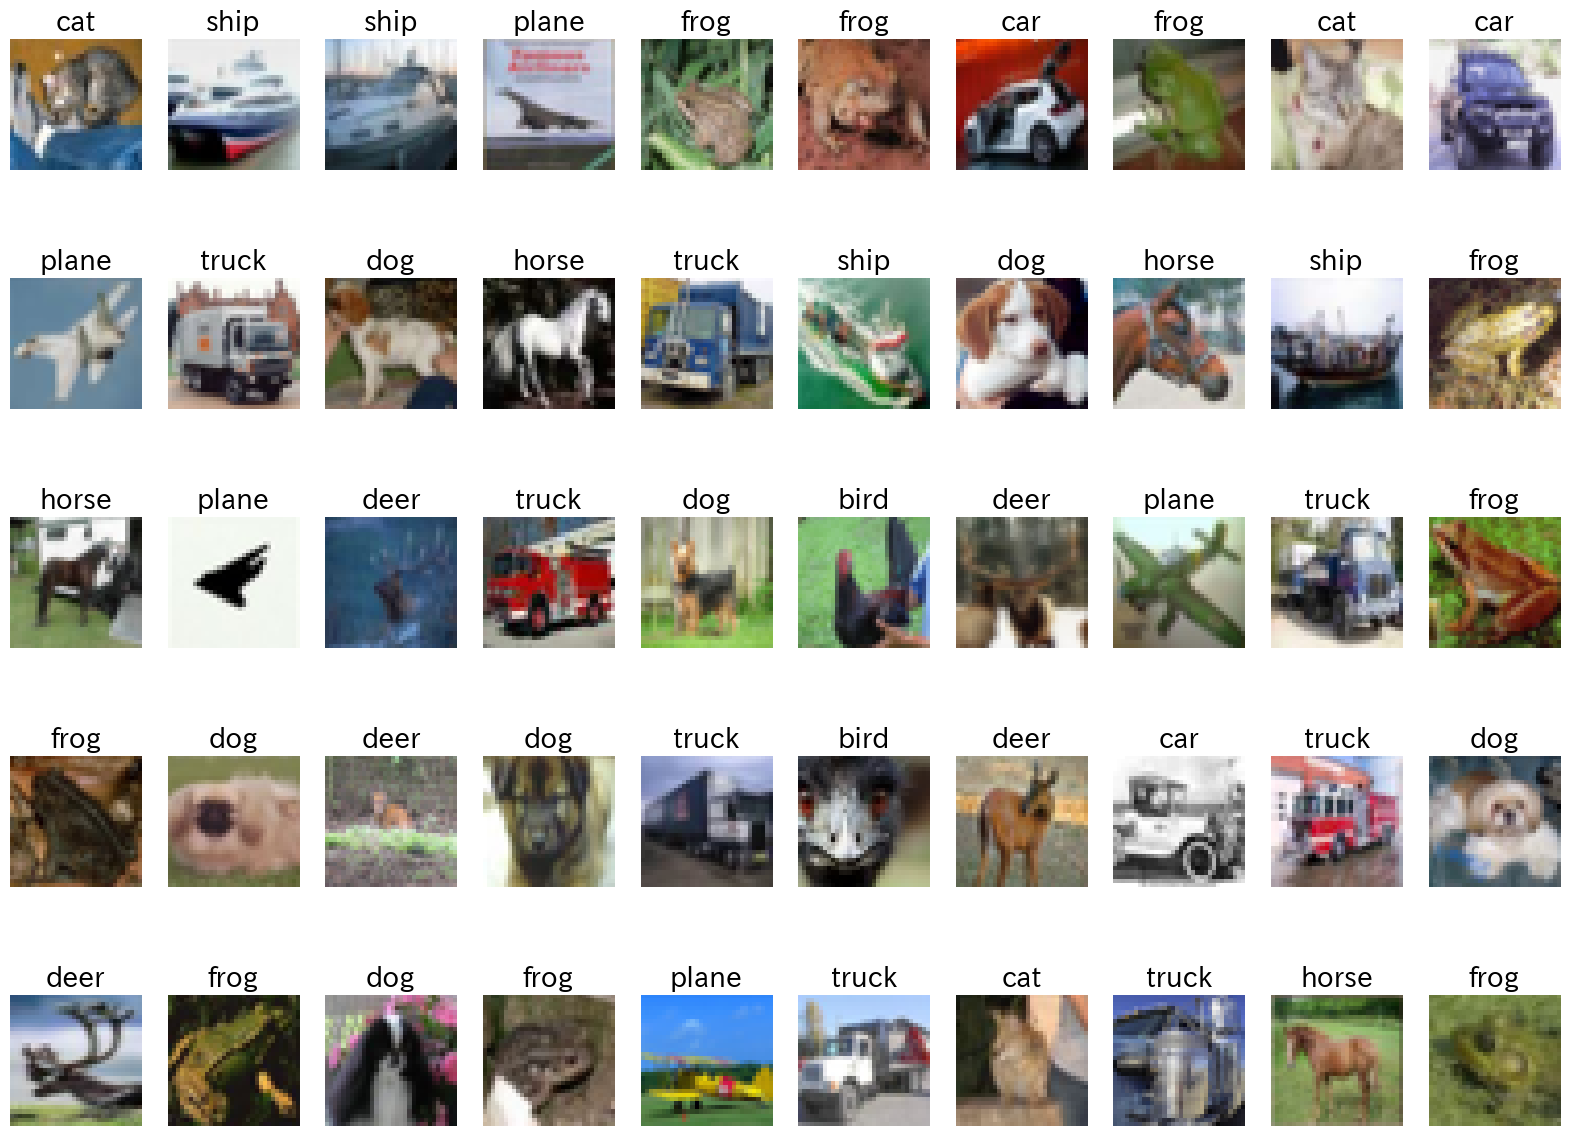

入力次元数：3072
出力次元数：10


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [1/10], loss: 2.15871 acc: 0.24376 val_loss: 2.05044, val_acc: 0.29910


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [2/10], loss: 1.99564 acc: 0.31030 val_loss: 1.94167, val_acc: 0.33520


...

Epoch [8/10], loss: 1.72865 acc: 0.40034 val_loss: 1.71712, val_acc: 0.40570


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [9/10], loss: 1.70820 acc: 0.40700 val_loss: 1.69879, val_acc: 0.41340


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [10/10], loss: 1.69002 acc: 0.41338 val_loss: 1.68146, val_acc: 0.41770


In [17]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
japanize_matplotlib.japanize()
from tqdm.notebook import tqdm
import torch
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchviz import make_dot

#############################
# 各種定数
#############################
num_epochs = 50 # 繰り返し回数
lr = 0.01  # 学習率
use_cuda = True # CUDA使用

# デバイスの割り当て
if use_cuda:
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
else:
  device = torch.device("cpu")
print(device)

# ダウンロード先ディレクトリ名
data_root = './data'
# テンソル化 ＋ 正規化 ＋ １階テンソル化
transform1 = transforms.Compose([
  # データのテンソル化
  transforms.ToTensor(),
  # データの正規化(Normalize(μ, σ) ⇒ (x - μ) / σ)
  transforms.Normalize(0.5, 0.5),
  # データを１階テンソルに変換
  transforms.Lambda(lambda x: x.view(-1)),
])

# テンソル化 ＋ 正規化のみ
transform2 = transforms.Compose([
  # データのテンソル化
  transforms.ToTensor(),
  # データの正規化(Normalize(μ, σ) ⇒ (x - μ) / σ)
  transforms.Normalize(0.5, 0.5),
])

# 訓練データ（１階テンソル）
train_set1 = datasets.CIFAR10(
  root=data_root,
  train=True,
  download=True,
  transform=transform1
)
# 検証データ（１階テンソル）
test_set1 = datasets.CIFAR10(
  root=data_root,
  train=False,
  download=True,
  transform=transform1
)

# 訓練データ（３階テンソル）
train_set2 = datasets.CIFAR10(
  root=data_root,
  train=True,
  download=True,
  transform=transform2
)
# 検証データ（３階テンソル）
test_set2 = datasets.CIFAR10(
  root=data_root,
  train=False,
  download=True,
  transform=transform2
)

# データ変換結果の確認
print('# 入力データの確認（１階テンソル版）')
image, label = train_set1[0]
print('訓練データの件数:', len(train_set1))
print('訓練データの型：', type(image))
print('訓練データのshape：', image.shape)
print('最小値：', image.data.min())
print('最大値：', image.data.max())
image, label = test_set1[0]
print('検証データの件数:', len(test_set1))
print('検証データの型：', type(image))
print('検証データのshape：', image.shape)
print('最小値：', image.data.min())
print('最大値：', image.data.max())

print('# 入力データの確認（３階テンソル版）')
image, label = train_set2[0]
print('訓練データの件数:', len(train_set2))
print('訓練データの型：', type(image))
print('訓練データのshape：', image.shape)
print('最小値：', image.data.min())
print('最大値：', image.data.max())
image, label = test_set2[0]
print('検証データの件数:', len(test_set2))
print('検証データの型：', type(image))
print('検証データのshape：', image.shape)
print('最小値：', image.data.min())
print('最大値：', image.data.max())

# 訓練用データローダー
# 訓練用なので、シャッフルをかける
train_loader1 = DataLoader(train_set1, batch_size = batch_size, shuffle = True,)
train_loader2 = DataLoader(train_set2, batch_size = batch_size, shuffle = True,)
# 検証用データローダー
# 検証用にシャッフルは不要
test_loader1 = DataLoader(test_set1, batch_size = batch_size, shuffle = False,)
test_loader2 = DataLoader(test_set2, batch_size = batch_size, shuffle = False,)

# データローダーの最初の１セットから、データの次元数を取得
images1, labels1 = next(iter(train_loader1))
images2, labels2 = next(iter(train_loader2))
print(f'１階テンソル版のshape:{images1.shape}')
print(f'３階テンソル版のshape:{images2.shape}')

# 正解ラベル定義
classes = (
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
)
# 検証データ最初の５０個の表示
show_images_labels(test_loader2, classes, None, None)
# 入力次元数　今回は 3×32×32=3072
n_input = image.view(-1).shape[0]
# 出力次元数
n_output = len(classes)
# 中間層次元数
n_hidden = 128
print(f"入力次元数：{n_input}")
print(f"出力次元数：{n_output}")
print(f"中間層次元数：{n_hidden}")

###################################################
# 関数定義
###################################################
class Net(torch.nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()
        # 中間層
        self.l1 = torch.nn.Linear(n_input, n_hidden)
        # 出力層
        self.l2 = torch.nn.Linear(n_hidden, n_output)
        # ReLU関数
        self.relu = torch.nn.ReLU(inplace=True)
        # 関数合成
        self.net = torch.nn.Sequential(
            self.l1,
            self.relu,
            self.l2,
        )

    # 予測計算
    def forward(self, inputs):
      return self.net(inputs)

# ###########################
# # メイン処理
# ###########################
torch_seed()
# 予測計算オブジェクトの作成
net = Net(n_input, n_output, n_hidden).to(device)
# 損失関数
criterion = torch.nn.CrossEntropyLoss()
# 最適化関数
optimizer = torch.optim.SGD(net.parameters(), lr=lr)
# 記録用配列初期化()
history = np.zeros((0, 5))
history = fit(net, optimizer, criterion, num_epochs, train_loader1, test_loader1, device, history)
# 評価
evaluate_history(history)
